<a href="https://colab.research.google.com/github/vinayakstha/heart-disease-prediction/blob/main/heart_disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('heart.csv')

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


(918, 12)

In [6]:

df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [9]:
categorical_cols = [
    "Sex",
    "ChestPainType",
    "FastingBS",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "HeartDisease"
]

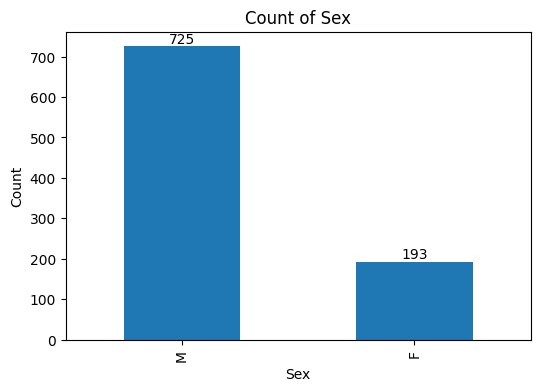

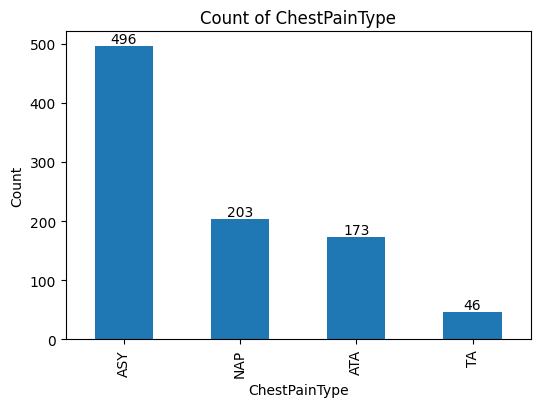

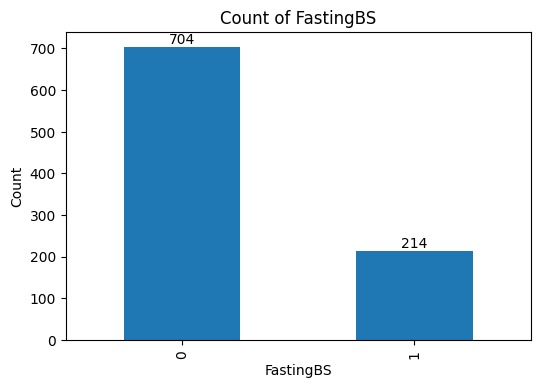

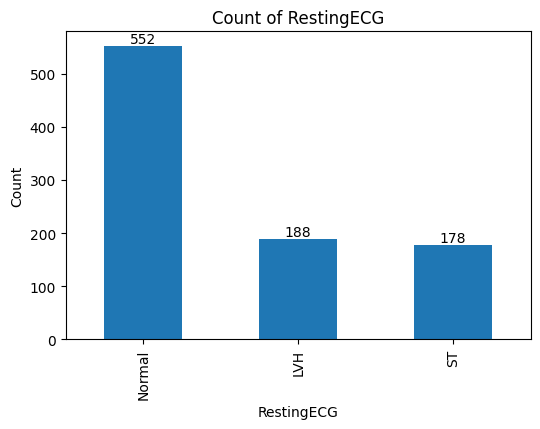

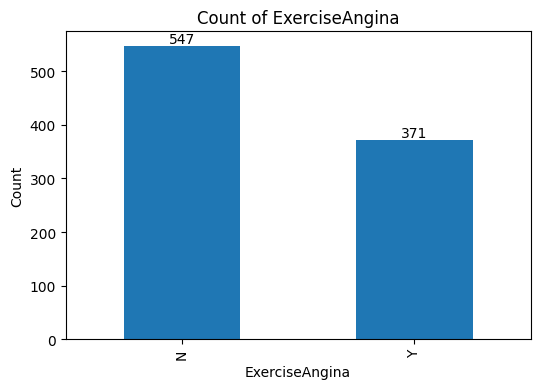

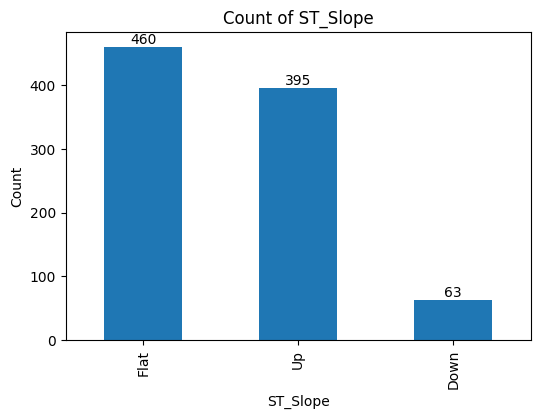

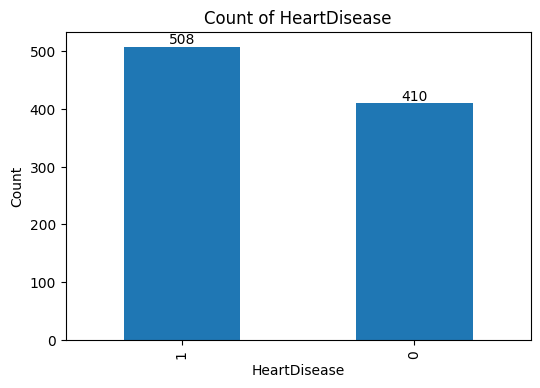

In [10]:
import matplotlib.pyplot as plt

for col in categorical_cols:

    counts = df[col].value_counts()

    plt.figure(figsize=(6,4))
    ax = counts.plot(kind="bar")

    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    # Data labels
    for container in ax.containers:
        ax.bar_label(container)

    plt.show()

<Figure size 600x400 with 0 Axes>

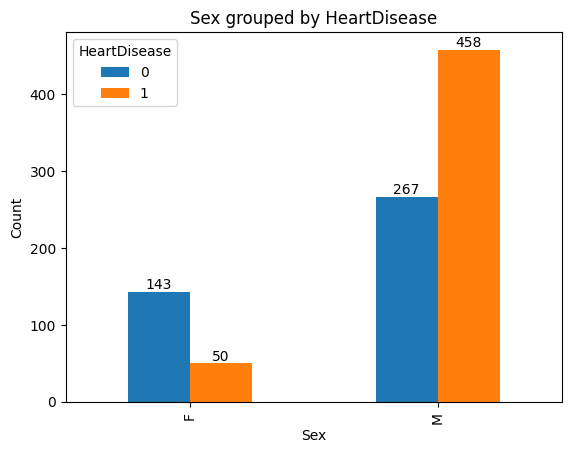

<Figure size 600x400 with 0 Axes>

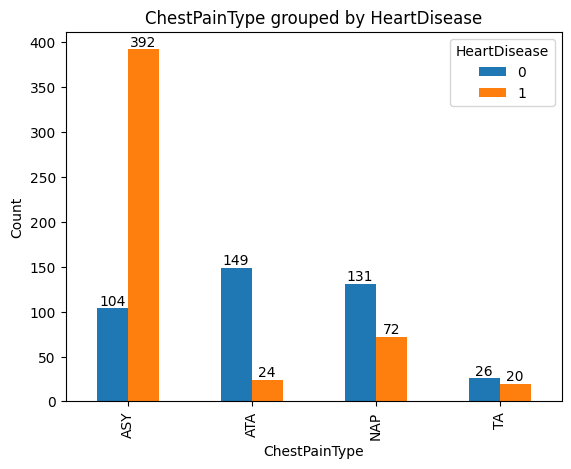

<Figure size 600x400 with 0 Axes>

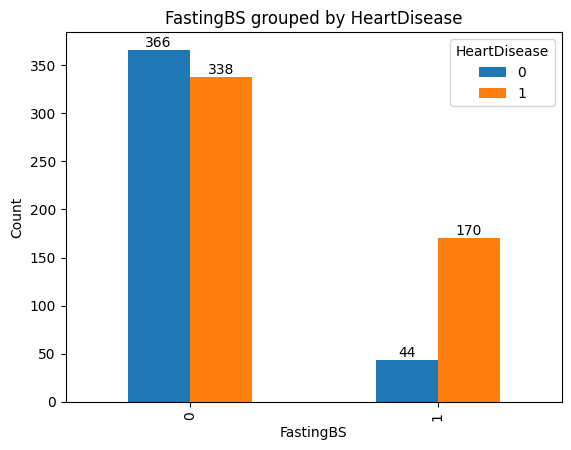

<Figure size 600x400 with 0 Axes>

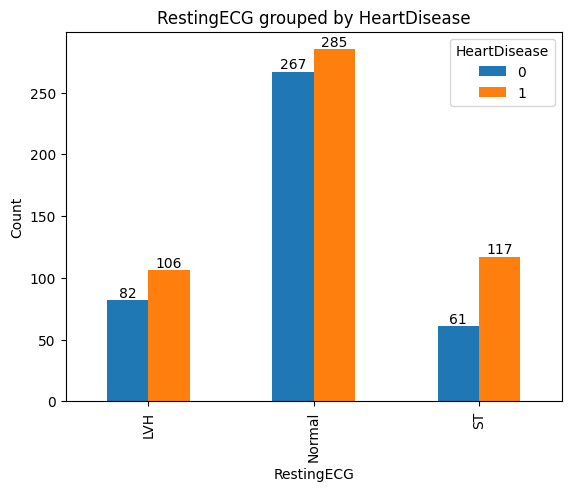

<Figure size 600x400 with 0 Axes>

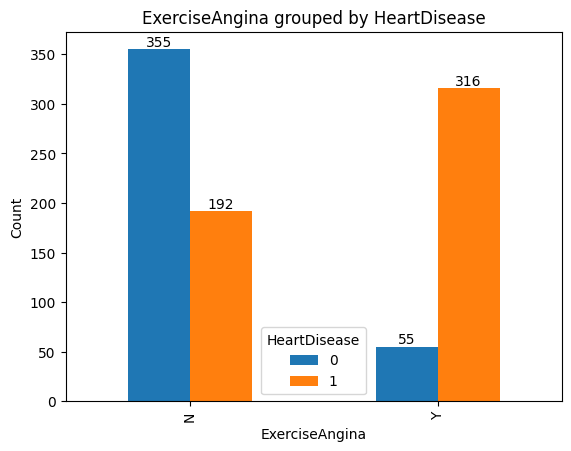

<Figure size 600x400 with 0 Axes>

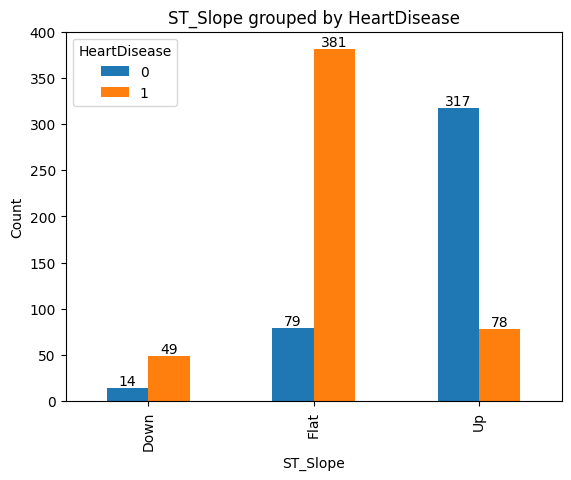

In [11]:
for col in categorical_cols:

    if col != "HeartDisease":

        grouped = df.groupby([col, "HeartDisease"]).size().unstack()

        plt.figure(figsize=(6,4))
        ax = grouped.plot(kind="bar")

        plt.title(f"{col} grouped by HeartDisease")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend(title="HeartDisease")

        # Data labels
        for container in ax.containers:
            ax.bar_label(container)

        plt.show()

In [12]:
heart_disease_patients = df[df["HeartDisease"] == 1]

male_over_50 = heart_disease_patients[
    (heart_disease_patients["Sex"] == "M") &
    (heart_disease_patients["Age"] > 50)
]

percentage = (len(male_over_50) / len(heart_disease_patients)) * 100

print(f"{percentage:.2f}%")

67.72%


In [13]:
median_age = heart_disease_patients["Age"].median()
print(median_age)

57.0


In [18]:
resting_bp_count = len(df[df['RestingBP'] == 0])
cholesterol_count = len(df[df['Cholesterol'] == 0])
print(resting_bp_count)
print(cholesterol_count)

1
172


In [19]:
df = df[df['RestingBP'] != 0]
df = df[df['Cholesterol'] != 0]

In [20]:
df_dummy = pd.get_dummies(df, drop_first=True)

In [22]:
corr = abs(df_dummy.corr())

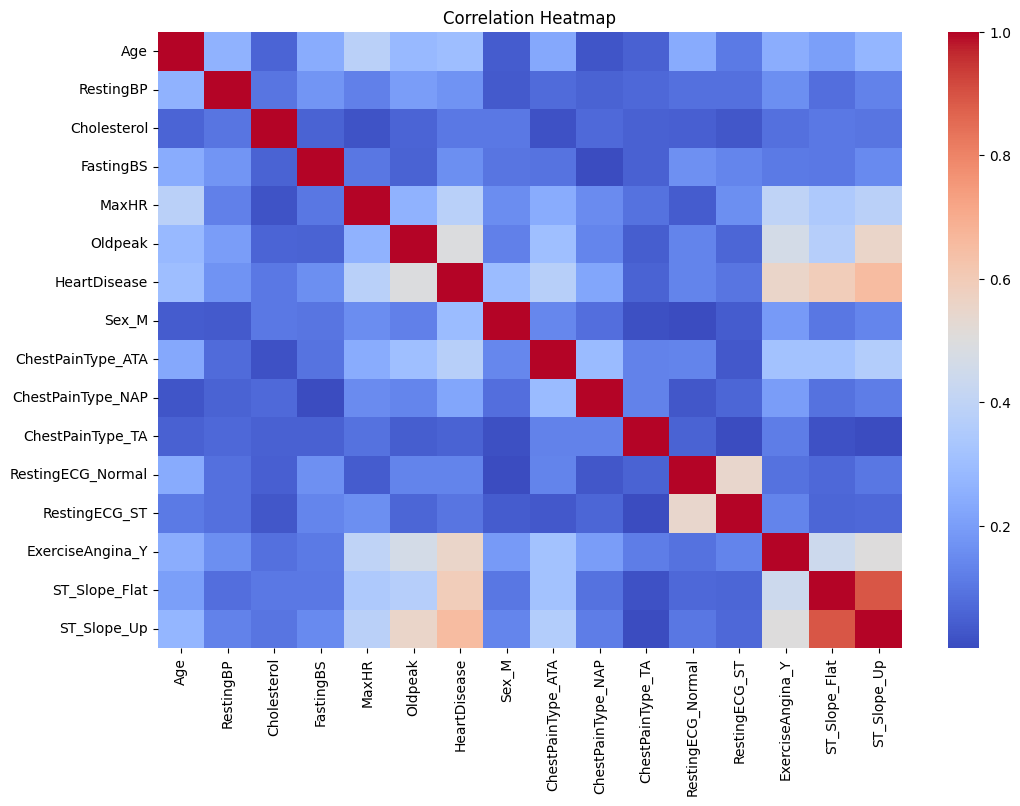

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [25]:
corr["HeartDisease"].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
ST_Slope_Up,0.653759
ST_Slope_Flat,0.591554
ExerciseAngina_Y,0.551834
Oldpeak,0.495696
MaxHR,0.377212
ChestPainType_ATA,0.375634
Age,0.298617
Sex_M,0.292779
ChestPainType_NAP,0.222146


In [27]:
X = df_dummy.drop('HeartDisease', axis=1)
y = df_dummy['HeartDisease']

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, random_state=417)

In [29]:
features = [
    "Oldpeak",
    "MaxHR",
    "Sex_M",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [31]:
for feature in features:
  knn = KNeighborsClassifier(n_neighbors=5)

  knn.fit(
      X_train[[feature]],
      y_train
  )
  y_pred = knn.predict(X_val[[feature]])
  accuracy = accuracy_score(y_val, y_pred)
  print(f"{feature}: {accuracy:.2f}")


Oldpeak: 0.68
MaxHR: 0.58
Sex_M: 0.57
ExerciseAngina_Y: 0.43
ST_Slope_Flat: 0.79
ST_Slope_Up: 0.81


In [32]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [33]:
selected_features = [
    "Oldpeak",
    "Sex_M",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

In [34]:
scaler = MinMaxScaler()

In [35]:
X_train_scaled = scaler.fit_transform(X_train[selected_features])

In [36]:
X_val_scaled = scaler.transform(X_val[selected_features])

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)

In [38]:
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.82


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features],
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [42]:
grid_params = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "manhattan"]
}

In [43]:
knn = KNeighborsClassifier()
grid = GridSearchCV(
    estimator=knn,
    param_grid=grid_params,
    scoring="accuracy",
    cv=5
)

In [46]:
grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_
X_test_scaled = scaler.transform(X_test)
y_pred = best_model.predict(X_test_scaled)

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.88
